In [1]:
from typing import List, TypedDict
import re 
import os

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain_huggingface import HuggingFaceEmbeddings 
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from dotenv import load_dotenv

load_dotenv()

C:\Users\shubh\AppData\Local\Temp\ipykernel_43224\3336210971.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


True

In [11]:
docs = (
    PyPDFLoader("./book1.pdf").load()
    + PyPDFLoader("./book2.pdf").load()
    + PyPDFLoader("./book3.pdf").load()
)

In [12]:
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [13]:
embeddings = HuggingFaceEmbeddings(model="sentence-transformers/all-MiniLM-L6-v2")
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 4})

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [14]:
llm = ChatNVIDIA(model="meta/llama-3.1-8b-instruct",
                 api_key=os.environ.get('NVIDIA_API_KEY'))

In [15]:
class State(TypedDict):
    question: str
    docs: List[Document]

    strips: List[str]            # output of decomposition (sentence strips)
    kept_strips: List[str]       # after filtering (kept sentences)
    refined_context: str         # recomposed internal knowledge (joined kept_strips)

    answer: str

In [16]:
def retrieve(state: State) -> State:
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [ ]:

def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]



class KeepOrDrop(BaseModel):
    keep: bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)



def refine(state: State) -> State:

    q = state["question"]

    # Combine retrieved docs into one context string
    context = "\n\n".join(d.page_content for d in state["docs"]).strip()

    # 1) DECOMPOSITION: context -> sentence strips
    strips = decompose_to_sentences(context)

    # 2) FILTER: keep only relevant strips
    kept: List[str] = []
    
    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    # 3) RECOMPOSE: glue kept strips back together (internal knowledge)
    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }


In [20]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
            "If the bullets are empty or insufficient, say: 'I don't know based on the provided books.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate(state: State) -> State:
    out = (answer_prompt | llm).invoke({"question": state["question"], "refined_context": state['refined_context']})
    return {"answer": out.content}

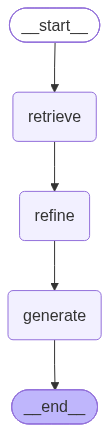

In [21]:
g = StateGraph(State)
g.add_node("retrieve", retrieve)
g.add_node("refine", refine)
g.add_node("generate", generate)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "refine")
g.add_edge("refine", "generate")
g.add_edge("generate", END)

app = g.compile()

app

In [22]:
res = app.invoke({
    "question": "Explain the bias–variance tradeoff",
    "docs": [],
    "strips": [],
    "kept_strips": [],
    "refined_context": "",
    "answer": ""
})
print(res["answer"])

• The bias–variance tradeoff refers to the balance between two key components that affect the performance of a model: bias and variance.
• Bias measures how far the model's predictions are from the true values, while variance measures how much the model's predictions vary across different data sets.
• A model with low bias tends to have high variance, meaning it may fit the training data well but not generalize well to new data.
• Conversely, a model with low variance tends to have high bias, meaning it may not fit the training data well but generalizes well to new data.
• The optimal model balances bias and variance, achieving the best predictive capability.


In [23]:
print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

3.2. The Bias-Variance Decomposition 151
Figure 3.6 Plot of squared bias and variance,
together with their sum, correspond-
ing to the results shown in Fig-
ure 3.5. Also shown is the average
test set error for a test data set size
of 1000 points. The minimum value
of (bias)2 + variance occurs around
ln λ = −0.31, which is close to the
value that gives the minimum error
on the test data.
lnλ
−3 −2 −1 0 1 2
0
0.03
0.06
0.09
0.12
0.15
(bias)2
variance
(bias)2 + variance
test error
ﬁt a model with 24 Gaussian basis functions by minimizing the regularized error
function (3.27) to give a prediction function y(l)(x) as shown in Figure 3.5. The
top row corresponds to a large value of the regularization coefﬁcientλ that gives low
variance (because the red curves in the left plot look similar) but high bias (because
****************************************************************************************************
with respect to multiple data sets.
We can also examine the bias-variance trade-

In [24]:
print(res['refined_context'])

The minimum value of (bias)2 + variance occurs around ln λ = −0.31, which is close to the value that gives the minimum error on the test data.
The top row corresponds to a large value of the regularization coefﬁcientλ that gives low variance (because the red curves in the left plot look similar) but high bias (because with respect to multiple data sets.
We can also examine the bias-variance trade-off quantitatively for this example.
As we shall see, there is a trade-off between bias and variance, with very ﬂexible models having low bias and high variance, and relatively rigid models having high bias and low variance.
The model with the optimal predictive capability is the one that leads to the best balance between bias and variance.
(4.5) We therefore see that the bias parameter w0 determines the location of the decision
